# Feature Building

In [1]:
# Phase 2, Step 1 — Build dataset using only HOG features
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import hog
from tqdm import tqdm  # progress bar

# ------------- CONFIG -------------
PREPROCESSED_DIR = "/home/pratyush/Desktop/DS_Project/data/preprocessed"
SPLIT_DIR        = "/home/pratyush/Desktop/DS_Project/data/splits"
OUT_DIR          = "/home/pratyush/Desktop/DS_Project/data/features"
os.makedirs(OUT_DIR, exist_ok=True)

GRID_W, GRID_H = 8, 8
TARGET_W, TARGET_H = 800, 600
CELL_W, CELL_H = TARGET_W // GRID_W, TARGET_H // GRID_H  # 100×75

# ------------- HOG SETTINGS -------------
def extract_hog_features(gray_cell):
    """Extracts HOG features for one grayscale cell (100×75)."""
    features = hog(
        gray_cell,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True
    )
    return features

# ------------- FEATURE EXTRACTOR FOR ONE IMAGE -------------
def extract_features_from_image(img_path, row_labels):
    """
    Split image into 8×8 cells, extract HOG for each, and return X, y.
    row_labels is a pandas Series for that image (contains c01..c64).
    """
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read {img_path}")
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    X_cells, y_cells = [], []

    for r in range(GRID_H):
        for c in range(GRID_W):
            x0, y0 = c * CELL_W, r * CELL_H
            cell = img[y0:y0+CELL_H, x0:x0+CELL_W]
            feat = extract_hog_features(cell)
            X_cells.append(feat)
            y_cells.append(row_labels[f"c{r*GRID_W + c + 1:02d}"])

    return np.array(X_cells), np.array(y_cells)

# ------------- MAIN LOOP FOR SPLIT -------------
import pandas as pd

def build_split_features(split_name):
    csv_path = os.path.join(SPLIT_DIR, f"{split_name}_labels.csv")
    df = pd.read_csv(csv_path)
    print(f"\nBuilding HOG features for {split_name} split with {len(df)} images")

    all_feats, all_labels, all_meta = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_name = row["image"]
        img_path = os.path.join(PREPROCESSED_DIR, img_name)
        X_cells, y_cells = extract_features_from_image(img_path, row)
        if X_cells is not None:
            all_feats.append(X_cells)
            all_labels.append(y_cells)
            all_meta += [(img_name, f"c{i:02d}") for i in range(1, 65)]

    X = np.vstack(all_feats)
    y = np.hstack(all_labels)

    # combine into a DataFrame
    df_out = pd.DataFrame(X)
    df_out.insert(0, "cell_id", [cid for _, cid in all_meta])
    df_out.insert(0, "image", [im for im, _ in all_meta])
    df_out["label"] = y.astype(int)

    out_csv = os.path.join(OUT_DIR, f"{split_name}_hog_features.csv")
    df_out.to_csv(out_csv, index=False)
    print(f"✅ Saved {split_name} features to {out_csv} ({df_out.shape[0]} rows)")


# ------------- RUN FOR ALL SPLITS -------------
for split in ["train", "val", "test"]:
    build_split_features(split)



Building HOG features for train split with 301 images


100%|██████████| 301/301 [00:24<00:00, 12.17it/s]


✅ Saved train features to /home/pratyush/Desktop/DS_Project/data/features/train_hog_features.csv (19264 rows)

Building HOG features for val split with 65 images


100%|██████████| 65/65 [00:05<00:00, 10.85it/s]


✅ Saved val features to /home/pratyush/Desktop/DS_Project/data/features/val_hog_features.csv (4160 rows)

Building HOG features for test split with 65 images


100%|██████████| 65/65 [00:05<00:00, 11.08it/s]


✅ Saved test features to /home/pratyush/Desktop/DS_Project/data/features/test_hog_features.csv (4160 rows)


# Model Training using Random Forest

/home/pratyush/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Train: (19264, 3168), Val: (4160, 3168), Test: (4160, 3168)

✅ Validation Accuracy: 0.7079
              precision    recall  f1-score   support

           0      0.744     0.858     0.797      2781
           1      0.586     0.405     0.479      1379

    accuracy                          0.708      4160
   macro avg      0.665     0.632     0.638      4160
weighted avg      0.692     0.708     0.692      4160



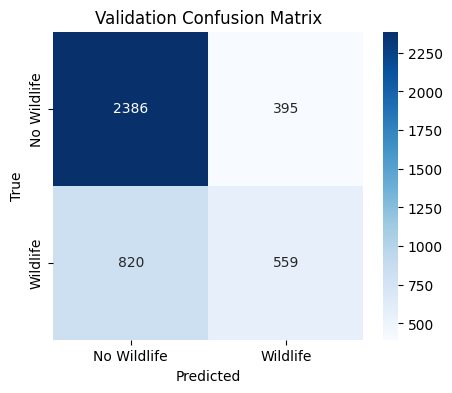


🧪 Test Accuracy: 0.7002

Test Set Performance:
              precision    recall  f1-score   support

           0      0.731     0.855     0.788      2716
           1      0.600     0.409     0.487      1444

    accuracy                          0.700      4160
   macro avg      0.666     0.632     0.637      4160
weighted avg      0.686     0.700     0.684      4160



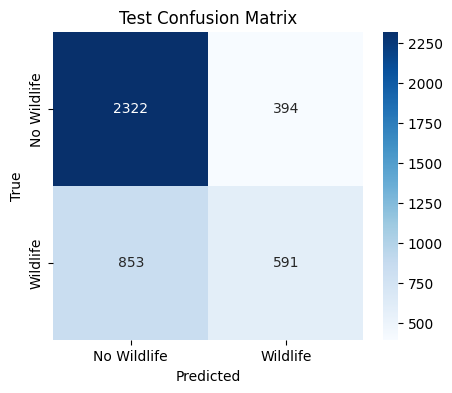

In [2]:
# Phase 3 — Baseline Model (HOG-only)
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- LOAD DATA ----------
FEATURE_DIR = "/home/pratyush/Desktop/DS_Project/data/features"

df_train = pd.read_csv(f"{FEATURE_DIR}/train_hog_features.csv")
df_val   = pd.read_csv(f"{FEATURE_DIR}/val_hog_features.csv")
df_test  = pd.read_csv(f"{FEATURE_DIR}/test_hog_features.csv")

# Separate features & labels
X_train = df_train.drop(["image","cell_id","label"], axis=1).values
y_train = df_train["label"].values
X_val   = df_val.drop(["image","cell_id","label"], axis=1).values
y_val   = df_val["label"].values
X_test  = df_test.drop(["image","cell_id","label"], axis=1).values
y_test  = df_test["label"].values

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ---------- TRAIN BASELINE RANDOM FOREST ----------
rf = RandomForestClassifier(
    n_estimators=120,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# ---------- VALIDATION EVALUATION ----------
y_pred_val = rf.predict(X_val)
acc_val = accuracy_score(y_val, y_pred_val)
print(f"\n✅ Validation Accuracy: {acc_val:.4f}")
print(classification_report(y_val, y_pred_val, digits=3))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Wildlife','Wildlife'], yticklabels=['No Wildlife','Wildlife'])
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------- TEST SET (only after tuning) ----------
y_pred_test = rf.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
print(f"\n🧪 Test Accuracy: {acc_test:.4f}")

# Optional classification report for test set
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_test, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Wildlife','Wildlife'], yticklabels=['No Wildlife','Wildlife'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
